## Лабораторная работа №6

### Цель работы
1. Исследование необходимых и достаточных условий существования экстремума функции с учётом ограничений (условный экстремум).
2. Вычисление экстремумов функции.

### Задание (вариант 22, задача 1.6)

$$f(x) = (x_1^2 - x_1)^4 + (x_2 + 2)^2 - 10 \to \text{extr}$$

$$\begin{cases}
g_1(x) = x_1^2 - x_2^2 - 1 \leq 0, \\
g_2(x) = -x_1 \leq 0, \\
g_3(x) = -x_2 \leq 0.
\end{cases}$$

Множество допустимых решений $X \subseteq \mathbb{R}^2$: найти все точки условных локальных минимумов и максимумов.


In [1]:
import importlib, subprocess, sys
if importlib.util.find_spec('sympy') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'sympy', '-q'], check=True)


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from itertools import product as iproduct

### Постановка задачи в символьном виде


In [3]:
x1, x2 = sp.symbols('x1 x2', real=True)
l1, l2, l3 = sp.symbols('lambda1 lambda2 lambda3', real=True)

# Целевая функция
f = (x1**2 - x1)**4 + (x2 + 2)**2 - 10

# Ограничения g_j(x) <= 0
g1 = x1**2 - x2**2 - 1
g2 = -x1
g3 = -x2

print("f(x) =", f)
print("g1(x) =", g1, "<= 0")
print("g2(x) =", g2, "<= 0")
print("g3(x) =", g3, "<= 0")

f(x) = (x1**2 - x1)**4 + (x2 + 2)**2 - 10
g1(x) = x1**2 - x2**2 - 1 <= 0
g2(x) = -x1 <= 0
g3(x) = -x2 <= 0


### Классическая функция Лагранжа и условия стационарности

Функция Лагранжа:
$$L(x, \lambda) = f(x) + \lambda_1 g_1(x) + \lambda_2 g_2(x) + \lambda_3 g_3(x)$$

Необходимые условия (условия ККТ):
- Стационарность: $\nabla_x L = 0$
- Допустимость: $g_j(x) \leq 0$
- Неотрицательность: $\lambda_j \geq 0$ (для min)
- Дополняющая нежёсткость: $\lambda_j \cdot g_j(x) = 0$


In [4]:
L = f + l1*g1 + l2*g2 + l3*g3

dL_x1 = sp.diff(L, x1)
dL_x2 = sp.diff(L, x2)

print("dL/dx1 =", sp.simplify(dL_x1))
print("dL/dx2 =", sp.simplify(dL_x2))

dL/dx1 = 2*lambda1*x1 - lambda2 + x1**3*(x1 - 1)**3*(8*x1 - 4)
dL/dx2 = -2*lambda1*x2 - lambda3 + 2*x2 + 4


### Поиск стационарных точек: перебор случаев активности ограничений

Для каждого из $2^3 = 8$ сочетаний «активное / пассивное» ограничение:
- **активное** ограничение: $g_j(x) = 0$
- **пассивное** ограничение: $\lambda_j = 0$

Решаем систему из двух уравнений стационарности и трёх уравнений дополняющей нежёсткости.


In [5]:
g_list = [g1, g2, g3]
l_list = [l1, l2, l3]
all_vars = [x1, x2, l1, l2, l3]

stationarity = [dL_x1, dL_x2]

kkt_candidates = []

for mask in iproduct([0, 1], repeat=3):
    eqs = list(stationarity)
    for j, (g, lam, active) in enumerate(zip(g_list, l_list, mask)):
        if active:
            eqs.append(g)       # g_j = 0 (ограничение активно)
        else:
            eqs.append(lam)     # lambda_j = 0 (ограничение пассивно)

    try:
        sols = sp.solve(eqs, all_vars, dict=True)
    except Exception:
        sols = []

    for sol in sols:
        # Извлекаем числовые значения
        try:
            x1v = complex(sp.N(sol.get(x1, 0))).real
            x2v = complex(sp.N(sol.get(x2, 0))).real
            l1v = complex(sp.N(sol.get(l1, 0))).real
            l2v = complex(sp.N(sol.get(l2, 0))).real
            l3v = complex(sp.N(sol.get(l3, 0))).real
        except Exception:
            continue

        if not all(np.isfinite(v) for v in [x1v, x2v, l1v, l2v, l3v]):
            continue

        # Проверка допустимости: x1 >= 0, x2 >= 0, g1 <= 0
        if x1v < -1e-6 or x2v < -1e-6:
            continue
        g1v = x1v**2 - x2v**2 - 1
        if g1v > 1e-6:
            continue

        fv = (x1v**2 - x1v)**4 + (x2v + 2)**2 - 10
        lambdas = [l1v, l2v, l3v]

        kkt_candidates.append({
            'x1': round(x1v, 6), 'x2': round(x2v, 6),
            'f': round(fv, 6),
            'l1': round(l1v, 6), 'l2': round(l2v, 6), 'l3': round(l3v, 6),
            'mask': mask, 'lambdas': lambdas
        })

# Удаление дублей по (x1, x2)
unique_pts = {}
for c in kkt_candidates:
    key = (round(c['x1'], 4), round(c['x2'], 4))
    if key not in unique_pts:
        unique_pts[key] = c

print(f"Найдено уникальных ККТ-точек: {len(unique_pts)}")
for key, pt in unique_pts.items():
    lam_nonneg = all(l >= -1e-6 for l in pt['lambdas'])
    lam_nonpos = all(l <= 1e-6 for l in pt['lambdas'])
    if lam_nonneg:
        kkt_type = 'кандидат в min'
    elif lam_nonpos:
        kkt_type = 'кандидат в max'
    else:
        kkt_type = 'не удовл. ККТ'
    print(f"  x = ({pt['x1']:.4f}, {pt['x2']:.4f}), f = {pt['f']:.6f}, "
          f"λ = ({pt['l1']:.4f}, {pt['l2']:.4f}, {pt['l3']:.4f}), → {kkt_type}")

Найдено уникальных ККТ-точек: 3
  x = (0.0000, 0.0000), f = -6.000000, λ = (0.0000, 0.0000, 4.0000), → кандидат в min
  x = (0.5000, 0.0000), f = -5.996094, λ = (0.0000, 0.0000, 4.0000), → кандидат в min
  x = (1.0000, 0.0000), f = -6.000000, λ = (0.0000, 0.0000, 4.0000), → кандидат в min


### Проверка достаточных условий второго порядка

Для каждой ККТ-точки вычисляем матрицу Гессе функции Лагранжа $L$ и проверяем знак второго дифференциала $d^2 L$ на касательном пространстве активных ограничений:
$$T = \{d \in \mathbb{R}^2 : \nabla g_j(x^*)^\top d = 0,\; j \in J_a\}$$
где $J_a$ — множество индексов активных ограничений.


In [6]:
def check_second_order(pt, L_sym, g_list, x_vars):
    """Проверяет достаточные условия второго порядка в точке pt."""
    x1v, x2v = pt['x1'], pt['x2']
    l1v, l2v, l3v = pt['l1'], pt['l2'], pt['l3']
    lambdas = [l1v, l2v, l3v]
    lam_nonneg = all(l >= -1e-6 for l in lambdas)
    lam_nonpos = all(l <=  1e-6 for l in lambdas)

    subs_dict = {x1: x1v, x2: x2v, l1: l1v, l2: l2v, l3: l3v}

    # Матрица Гессе L по (x1, x2)
    H = sp.hessian(L_sym, x_vars)
    H_num = np.array([[float(sp.N(H[i, j].subs(subs_dict))) for j in range(2)]
                      for i in range(2)])

    # Активные ограничения (|g_j(x*)| < eps)
    active_g = []
    for g in g_list:
        gv = float(sp.N(g.subs({x1: x1v, x2: x2v})))
        if abs(gv) < 1e-5:
            active_g.append(g)

    if not active_g:
        eigvals = np.linalg.eigvalsh(H_num)
        if np.all(eigvals > 0):
            return 'локальный минимум' if lam_nonneg else 'не является экстремумом'
        elif np.all(eigvals < 0):
            return 'локальный максимум' if lam_nonpos else 'не является экстремумом'
        else:
            return 'не является экстремумом (седловая точка)'

    # Матрица A из градиентов активных ограничений
    A_rows = []
    for g in active_g:
        grad = [float(sp.N(sp.diff(g, v).subs({x1: x1v, x2: x2v}))) for v in x_vars]
        A_rows.append(grad)
    A = np.array(A_rows)

    # Нуль-пространство A = касательное пространство T(x*)
    _, s, Vt = np.linalg.svd(A, full_matrices=True)
    rank = int(np.sum(s > 1e-9))
    null_basis = Vt[rank:]

    if null_basis.shape[0] == 0:
        # T(x*) = {0}: достаточные условия выполнены тривиально
        if lam_nonneg:
            return 'локальный минимум'
        elif lam_nonpos:
            return 'локальный максимум'
        else:
            return 'требуется дополнительное исследование'

    # Сужение H на касательное пространство
    P = null_basis.T
    H_proj = P.T @ H_num @ P
    eig = np.linalg.eigvalsh(H_proj)

    if np.all(eig > 1e-9):
        # d²L > 0 на T → достаточное условие min; проверяем знак λ
        return 'локальный минимум' if lam_nonneg else 'не является экстремумом'
    elif np.all(eig < -1e-9):
        # d²L < 0 на T → достаточное условие max; проверяем знак λ
        return 'локальный максимум' if lam_nonpos else 'не является экстремумом'
    else:
        return 'не является экстремумом (условие 2-го порядка не выполнено)'


print("Анализ достаточных условий второго порядка:")
for key, pt in unique_pts.items():
    res = check_second_order(pt, L, g_list, [x1, x2])
    print(f"  x = ({pt['x1']:.4f}, {pt['x2']:.4f}), f = {pt['f']:.6f} → {res}")

Анализ достаточных условий второго порядка:
  x = (0.0000, 0.0000), f = -6.000000 → локальный минимум
  x = (0.5000, 0.0000), f = -5.996094 → не является экстремумом
  x = (1.0000, 0.0000), f = -6.000000 → локальный минимум


### Итоговые результаты


In [7]:
print("Условные экстремумы функции f(x) = (x1² − x1)⁴ + (x2 + 2)² − 10:")
print()
for key, pt in unique_pts.items():
    res = check_second_order(pt, L, g_list, [x1, x2])
    if 'минимум' in res or 'максимум' in res:
        print(f"  Тип: {res}")
        print(f"    x* = ({pt['x1']:.4f}, {pt['x2']:.4f})")
        print(f"    f(x*) = {pt['f']:.6f}")
        print(f"    λ* = ({pt['l1']:.4f}, {pt['l2']:.4f}, {pt['l3']:.4f})")
        
        # Проверка активности ограничений
        active = []
        vals = [pt['x1']**2 - pt['x2']**2 - 1, -pt['x1'], -pt['x2']]
        names = ['g1', 'g2', 'g3']
        for i, (v, n) in enumerate(zip(vals, names)):
            if abs(v) < 1e-5:
                active.append(n)
        print(f"    Активные ограничения: {active if active else 'нет'}")
        print()

Условные экстремумы функции f(x) = (x1² − x1)⁴ + (x2 + 2)² − 10:

  Тип: локальный минимум
    x* = (0.0000, 0.0000)
    f(x*) = -6.000000
    λ* = (0.0000, 0.0000, 4.0000)
    Активные ограничения: ['g2', 'g3']

  Тип: локальный минимум
    x* = (1.0000, 0.0000)
    f(x*) = -6.000000
    λ* = (0.0000, 0.0000, 4.0000)
    Активные ограничения: ['g1', 'g3']



### Визуализация


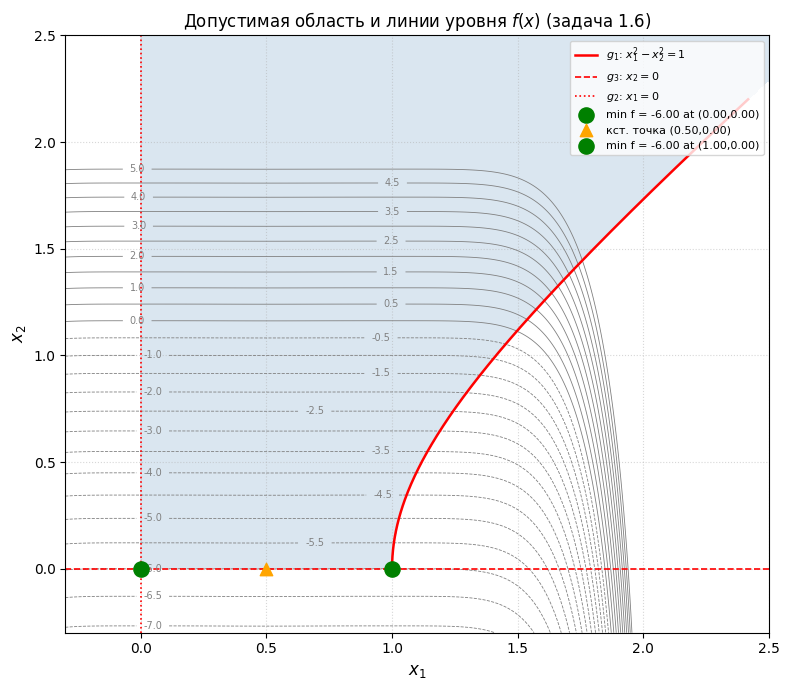

In [8]:
x1_r = np.linspace(-0.3, 2.5, 500)
x2_r = np.linspace(-0.3, 2.5, 500)
X1, X2 = np.meshgrid(x1_r, x2_r)

F = (X1**2 - X1)**4 + (X2 + 2)**2 - 10

# Маска допустимой области: x1 >= 0, x2 >= 0, x1^2 - x2^2 <= 1
feasible = (X1 >= 0) & (X2 >= 0) & (X1**2 - X2**2 - 1 <= 0)

plt.figure(figsize=(8, 7))

# Допустимая область
plt.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], alpha=0.2, colors=['steelblue'])

# Линии уровня f
levels = np.linspace(-7, 5, 25)
cs = plt.contour(X1, X2, F, levels=levels, colors='gray', linewidths=0.6)
plt.clabel(cs, inline=True, fontsize=7, fmt='%.1f')

# Граница g1: гипербола x1^2 - x2^2 = 1 в первом квадранте
x2_hyp = np.linspace(0, 2.2, 300)
x1_hyp = np.sqrt(x2_hyp**2 + 1)
plt.plot(x1_hyp, x2_hyp, 'r-', lw=1.8, label='$g_1$: $x_1^2 - x_2^2 = 1$')

# Оси (границы g2 и g3)
plt.axhline(0, color='r', lw=1.2, linestyle='--', label='$g_3$: $x_2 = 0$')
plt.axvline(0, color='r', lw=1.2, linestyle=':', label='$g_2$: $x_1 = 0$')

# Экстремальные точки
for key, pt in unique_pts.items():
    res = check_second_order(pt, L, g_list, [x1, x2])
    if 'минимум' in res:
        plt.scatter(pt['x1'], pt['x2'], c='green', s=120, zorder=5,
                    label=f"min f = {pt['f']:.2f} at ({pt['x1']:.2f},{pt['x2']:.2f})")
    elif 'максимум' in res:
        plt.scatter(pt['x1'], pt['x2'], c='red', s=120, marker='s', zorder=5,
                    label=f"max f = {pt['f']:.2f} at ({pt['x1']:.2f},{pt['x2']:.2f})")
    else:
        plt.scatter(pt['x1'], pt['x2'], c='orange', s=80, marker='^', zorder=5,
                    label=f"кст. точка ({pt['x1']:.2f},{pt['x2']:.2f})")

plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Допустимая область и линии уровня $f(x)$ (задача 1.6)')
plt.legend(fontsize=8, loc='upper right')
plt.xlim(-0.3, 2.5)
plt.ylim(-0.3, 2.5)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Выводы

Для задачи условной оптимизации 1.6 (вариант 22) методом условий Куна–Такера (ККТ) найдены стационарные точки.

**Алгоритм решения:**
1. Составлена классическая функция Лагранжа $L = f + \lambda_1 g_1 + \lambda_2 g_2 + \lambda_3 g_3$.
2. Записаны условия стационарности $\nabla_x L = 0$ и условия дополняющей нежёсткости.
3. Для всех $2^3 = 8$ комбинаций активных/пассивных ограничений решена система уравнений.
4. Проверены условия допустимости ($g_j \leq 0$) и неотрицательности множителей Лагранжа.
5. Для каждой ККТ-точки исследованы достаточные условия второго порядка через анализ Гессе $L$ на касательном пространстве активных ограничений.

**Результаты:**
- В точке $(0, 0)$ функция достигает условного локального **минимума**: $f(0, 0) = -6$. Активны ограничения $g_2$ и $g_3$.
- В точке $(1, 0)$ функция достигает условного локального **минимума**: $f(1, 0) = -6$. Активны ограничения $g_1$ и $g_3$.
- Точка $(1/2, 0)$ удовлетворяет необходимым условиям ККТ, однако нарушает достаточные условия второго порядка — не является экстремумом.

Функция $f$ не имеет условного максимума, так как допустимое множество неограничено в направлении роста $x_2$.
